# Does putting more pixels on the board help?

PCB1 development comparison, October2,2026. The original result is preserved.
C1 uses a conservative content-derived crop with aspect preservation at256 pixels;
C2 repeats that geometry at512. Both retain frozen ResNet18 and4096 uniformly
sampled normal patches. No training or PCB2 evaluation occurred.

This notebook reads saved tables/charts only. It does not run inference, refit a
reference bank or select a threshold. Full interpretation and limitations are in
`artifacts/pcb1_geometry_comparison/findings.md`.

In [1]:
from pathlib import Path
import json,hashlib
import pandas as pd
from IPython.display import display,Image
root=Path.cwd()
if not (root/'artifacts').exists():root=root.parent
folder=root/'artifacts/pcb1_geometry_comparison'
meta=json.loads((folder/'comparison_metadata.json').read_text())
for name,expected in meta['outputs'].items():
 assert hashlib.sha256((folder/name).read_bytes()).hexdigest()==expected
for size in [256,512]:
 review=json.loads((root/f'artifacts/runs/geometry_{size}_v1/independent_review.json').read_text())
 assert review['passed']
print('Saved comparison tables/charts verified; both independent reviews passed.')

Saved comparison tables/charts verified; both independent reviews passed.


## The geometry check came first

The rule finds a large connected blue area and adds space around its sides and
connector ends. It falls back to the whole image if the region is implausible.
It is designed specifically for these blue PCB1 boards. It does not rotate or
register boards. The audit checked all904 fitting/calibration normals; visual
review covered14 systematic examples including crop-size extremes.

,normal_count,fallback_count,median_crop_fraction,visual_samples
0,904,0,0.595701,14


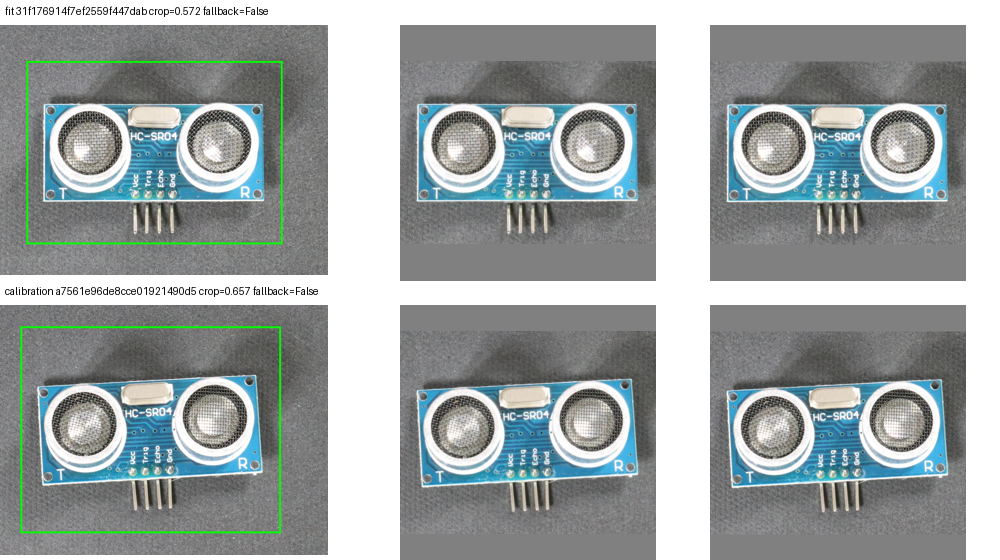

In [2]:
audit=json.loads((root/'artifacts/pcb1_geometry/audit.json').read_text())
display(pd.DataFrame([{'normal_count':audit['normal_count'],'fallback_count':audit['fallback_count'],'median_crop_fraction':audit['crop_area_quantiles']['0.5'],'visual_samples':len(audit['selection_ids'])}]))
display(Image(filename=str(root/'artifacts/pcb1_geometry/normal_contact_sheet_03.png')))

## Compare all three recipes

Thresholds are separately calibrated from the same181 normal boards under the
original95th/99th quantile policy. Recall and false alarms must be read together.
A retrospective A2 threshold was never substituted. Pixel AP describes ranking;
it is not detection probability. The median reflects a typical anomalous image,
whereas pooled AP can be dominated by large easy defects.

,recipe,image_ap,auroc,recall,fpr,median_pixel_ap,pooled_pixel_ap,iou,peak_inside_count,overlap_count,source_median_pixel_ap,inference_median_seconds
0,Run1 direct256,0.851568,0.8654,0.43,0.09,0.039337,0.791977,0.121817,26,79,NaN,0.306921
1,C1 crop256,0.905606,0.9082,0.61,0.04,0.096820,0.813358,0.118186,30,92,0.091931,0.291909
2,C2 crop512,0.903110,0.9133,0.70,0.12,0.353520,0.686319,0.127311,50,98,0.352321,1.080967


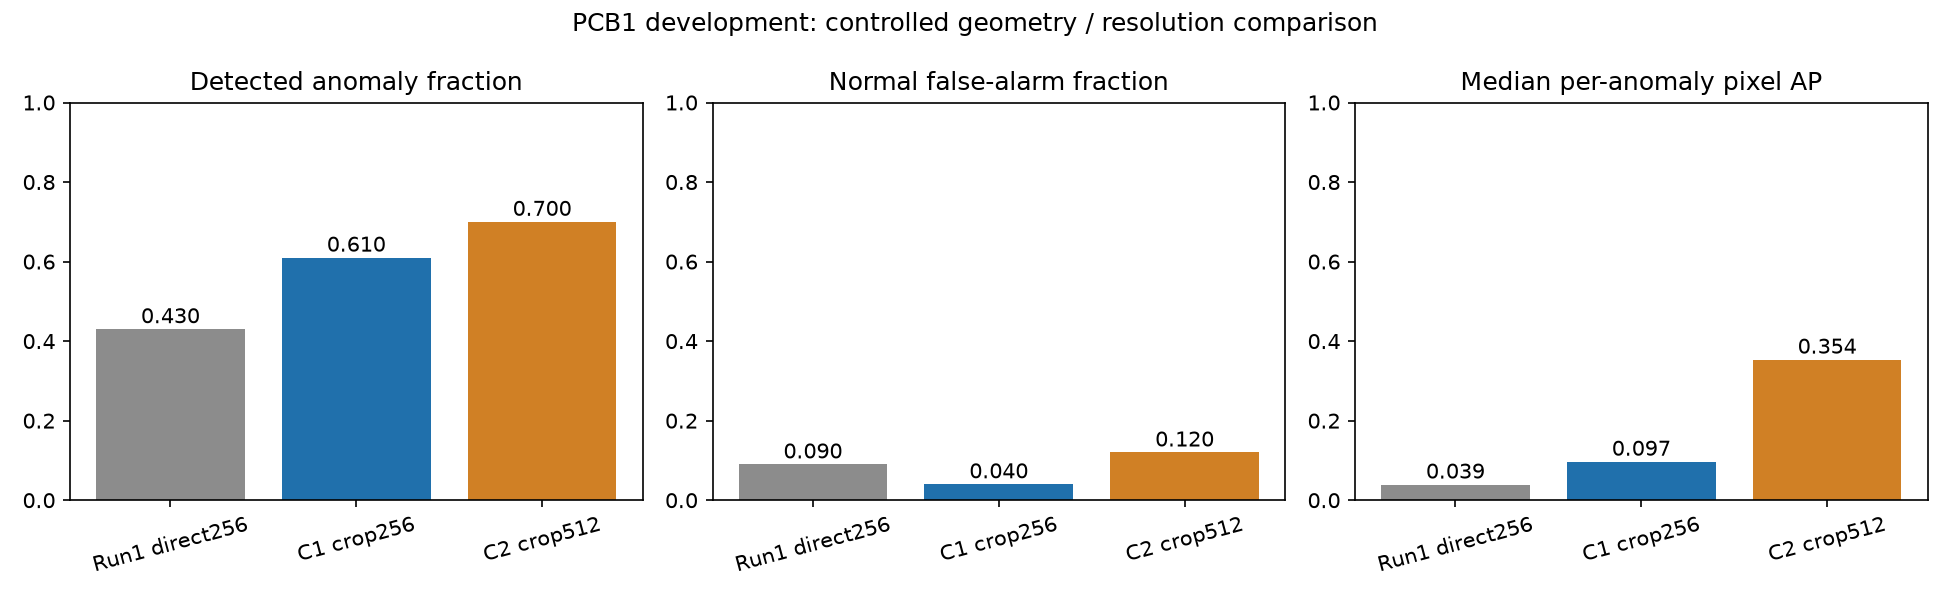

,recipe,defect_type,sample_count,detected_count,recall
0,Run1 direct256,bent,15,12,0.800000
1,Run1 direct256,melt,54,19,0.351852
2,Run1 direct256,missing,20,14,0.700000
3,Run1 direct256,scratch,21,3,0.142857
4,C1 crop256,bent,15,15,1.000000
5,C1 crop256,melt,54,25,0.462963
6,C1 crop256,missing,20,16,0.800000
7,C1 crop256,scratch,21,11,0.523810
8,C2 crop512,bent,15,14,0.933333
9,C2 crop512,melt,54,35,0.648148


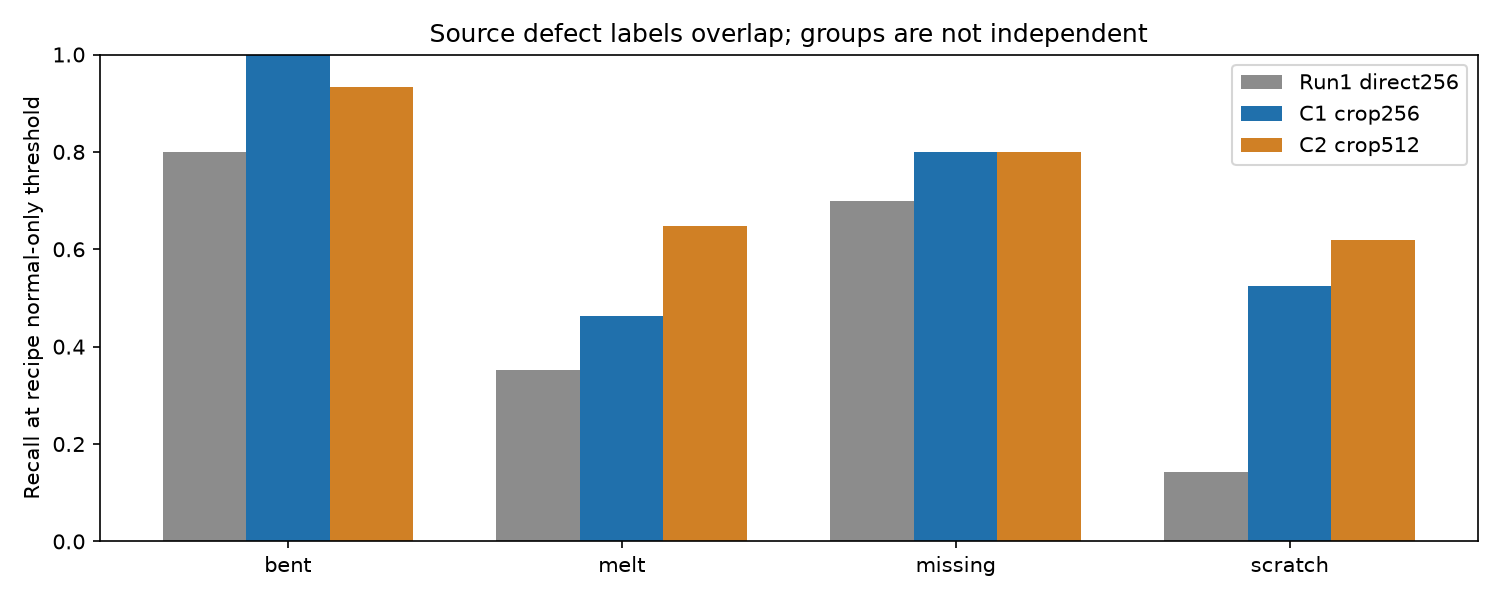

In [3]:
display(pd.read_csv(folder/'comparison.csv'))
display(Image(filename=str(folder/'comparison.png')))
display(pd.read_csv(folder/'type_recall_comparison.csv'))
display(Image(filename=str(folder/'type_recall.png')))

## Resources and geometry failures

Fixed4096 memory means lower patch coverage at512. Sampling is uniform, not a
coreset. Streamed extraction avoids allocating a full raw fitting feature bank.
Times below include source hashing in the new runs; original published latency
excluded raw hashing. Do not treat their difference as a perfectly matched timing
benchmark. Full-image evaluation keeps pixels outside the crop; their score is zero.
Any ground truth cropped out is still counted and reported.

In [4]:
rows=[]
for size in [256,512]:
 p=root/f'artifacts/runs/geometry_{size}_v1'
 runtime=json.loads((p/'normal_runtime.json').read_text());bank=json.loads((p/'memory_metadata.json').read_text());m=json.loads((p/'metrics.json').read_text())
 rows.append({'size':size,'memory_fraction':bank['fraction'],'memory_count':bank['count'],**runtime,**m['geometry']})
display(pd.DataFrame(rows))

,size,memory_fraction,memory_count,preparation_seconds,peak_rss_bytes,median_inference_seconds,p95_inference_seconds,fallback_count,anomaly_with_annotation_outside_crop_count,maximum_annotation_outside_fraction
0,256,0.005533,4096,74.925586,893829120,0.288049,0.291745,0,0,0.0
1,512,0.001383,4096,239.432922,1116454912,1.077875,1.095430,0,0,0.0


## Same examples, side by side

The eleven example IDs were fixed in A2 before these experiments. All maps are
shown in the same full-image256 view. Cyan is the source annotation. The display
shows map divided by that recipe's pixel threshold on a shared0–2 scale; this is
for comparison only and does not change any metric or imply probability.

,image_id,reasons
0,de611bce473c840af8adafcd,"[""TP: strongest per-image localization""]"
1,ca6517206c7ed606f1334b73,"[""TP: weakest per-image localization""]"
2,d974322eff775a646b101f0e,"[""FN: nearest below image threshold""]"
3,ef6143041222529aa5aaae7c,"[""FN: lowest image score""]"
4,d513967cbf2cbf166191b214,"[""Smallest-area quartile""]"
5,d9a35e62add18f84d5fe6ab2,"[""bent: middle score-ranked image""]"
6,cf0b7d2b92f0fb2e900016bc,"[""melt: middle score-ranked image""]"
7,f8c75b3d35149a713c6f9194,"[""missing: middle score-ranked image""]"
8,06a000c3b7f783f28804f8a4,"[""scratch: middle score-ranked image""]"
9,122c351f4783e562322ae0b4,"[""FP: middle score-ranked normal""]"


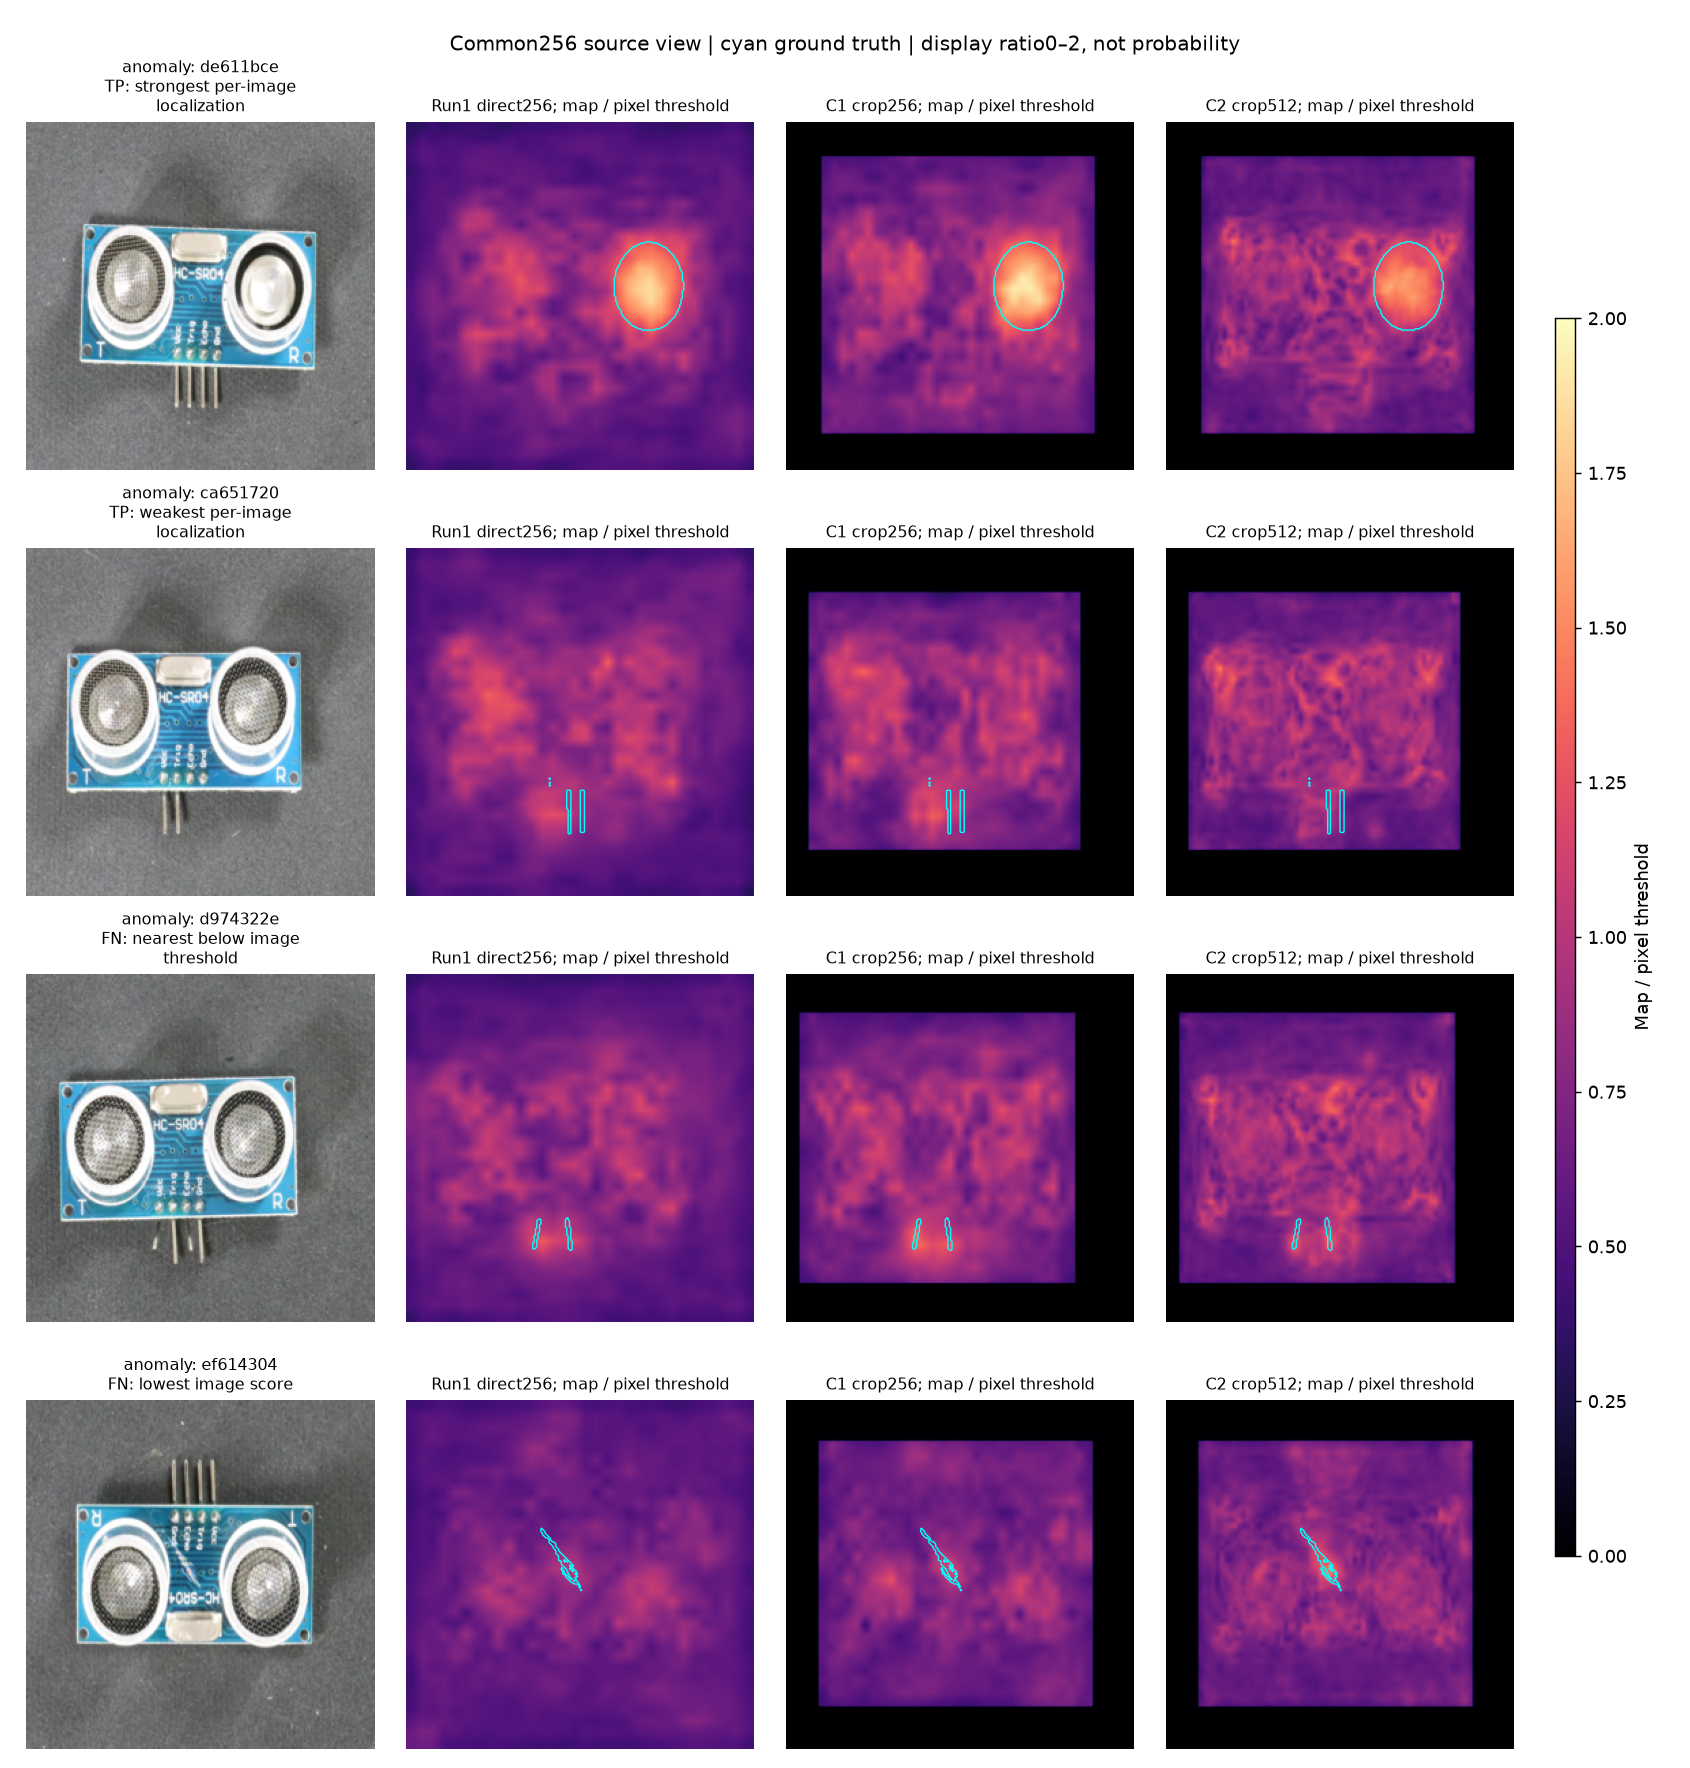

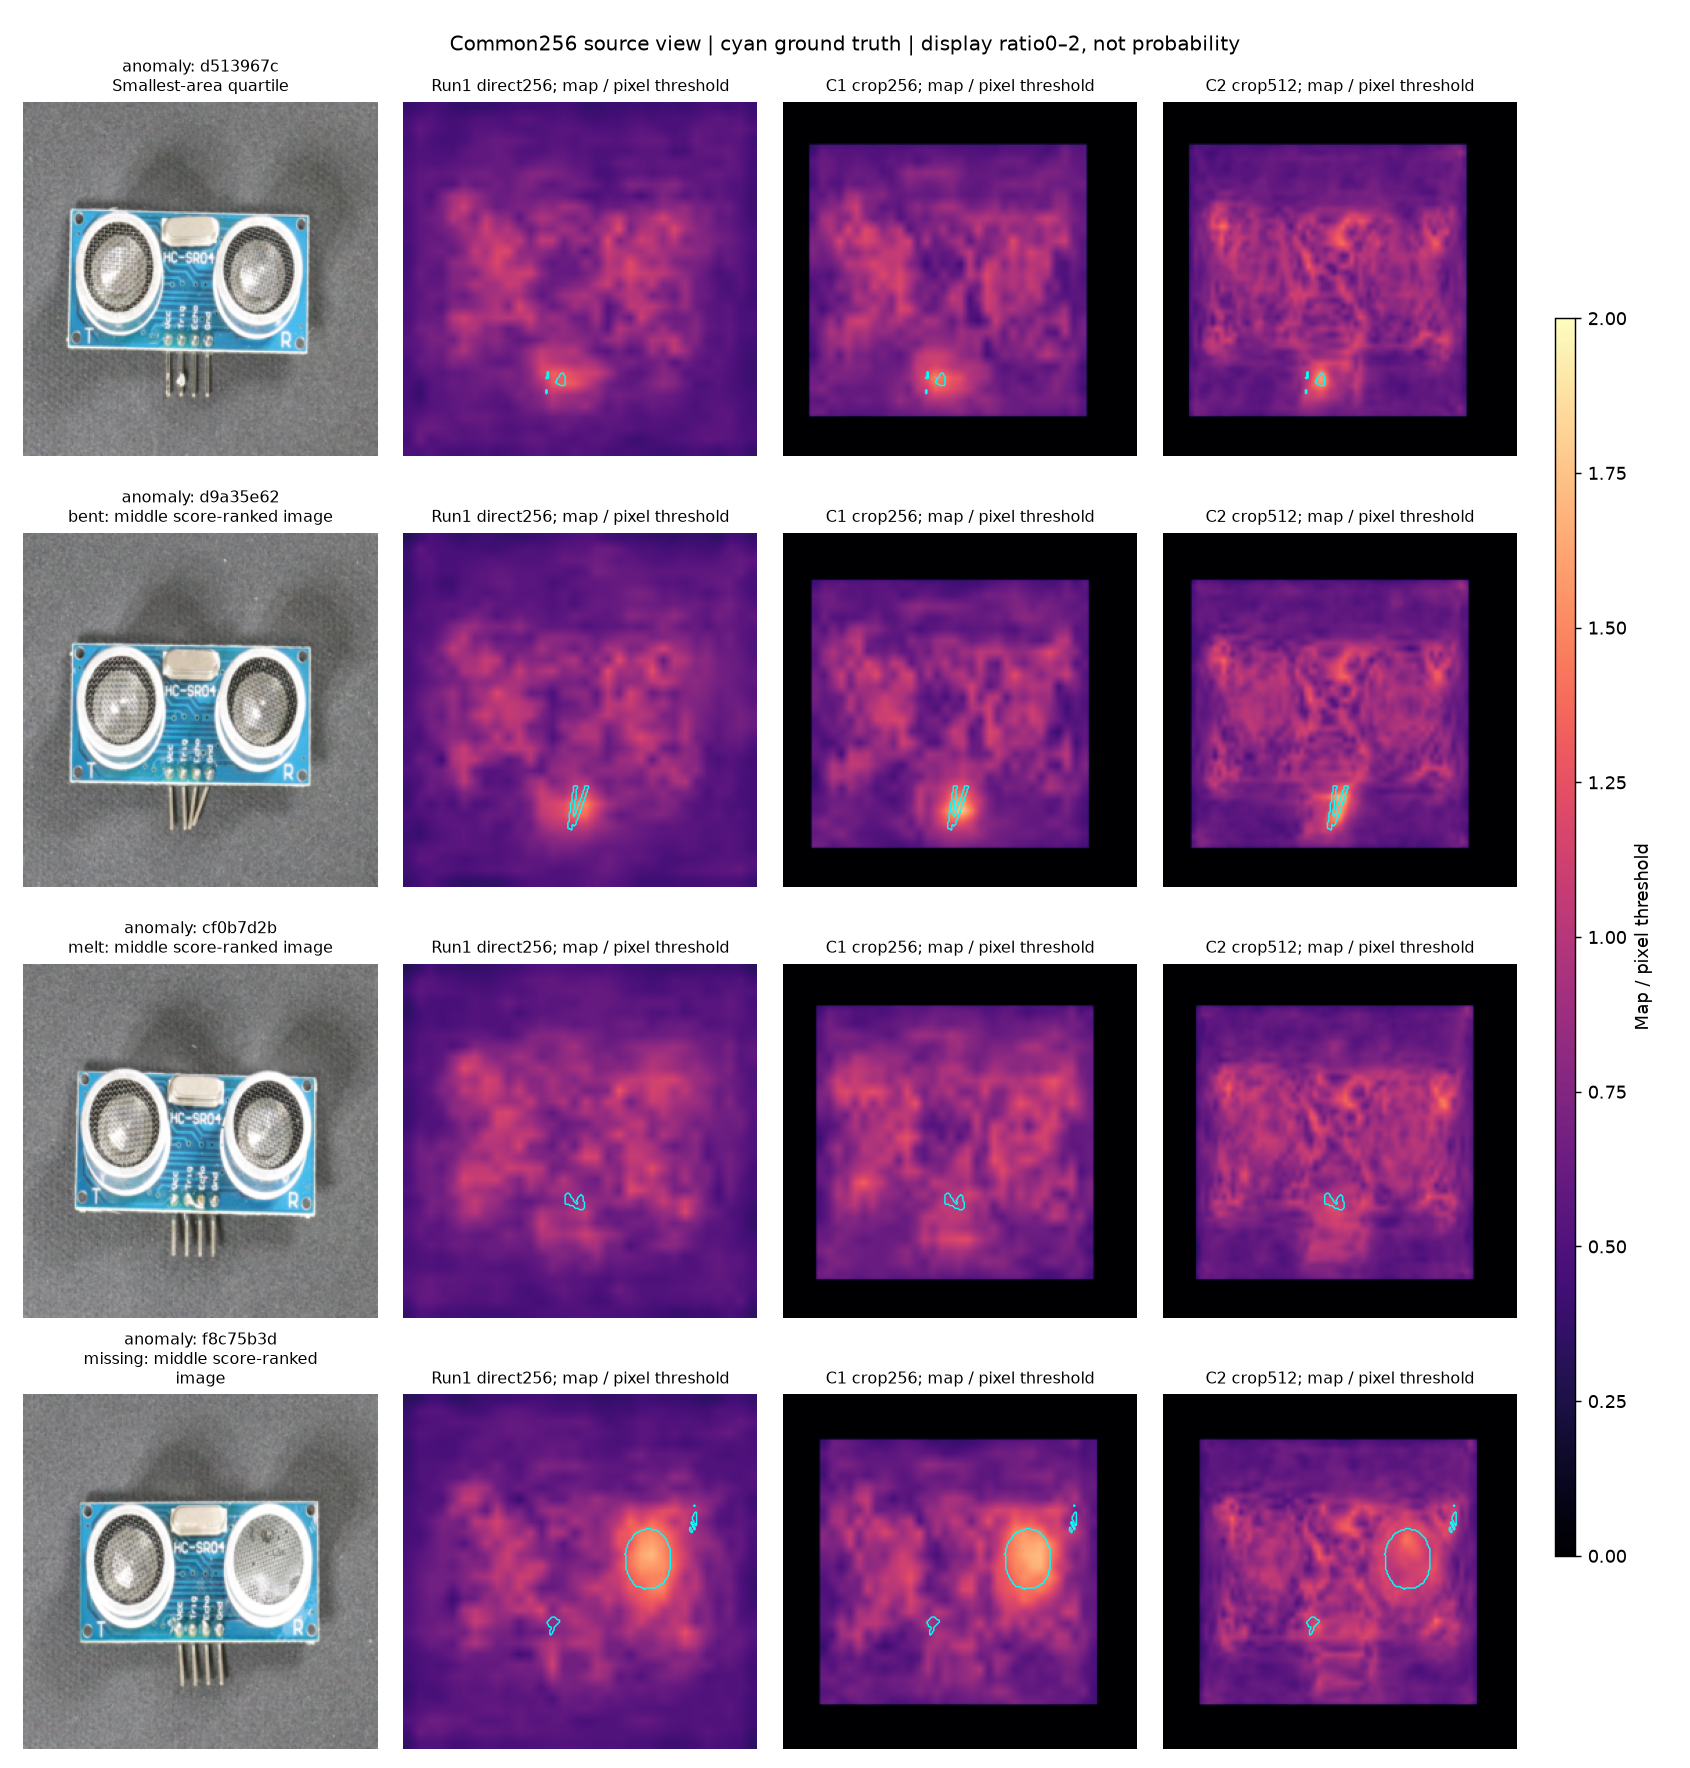

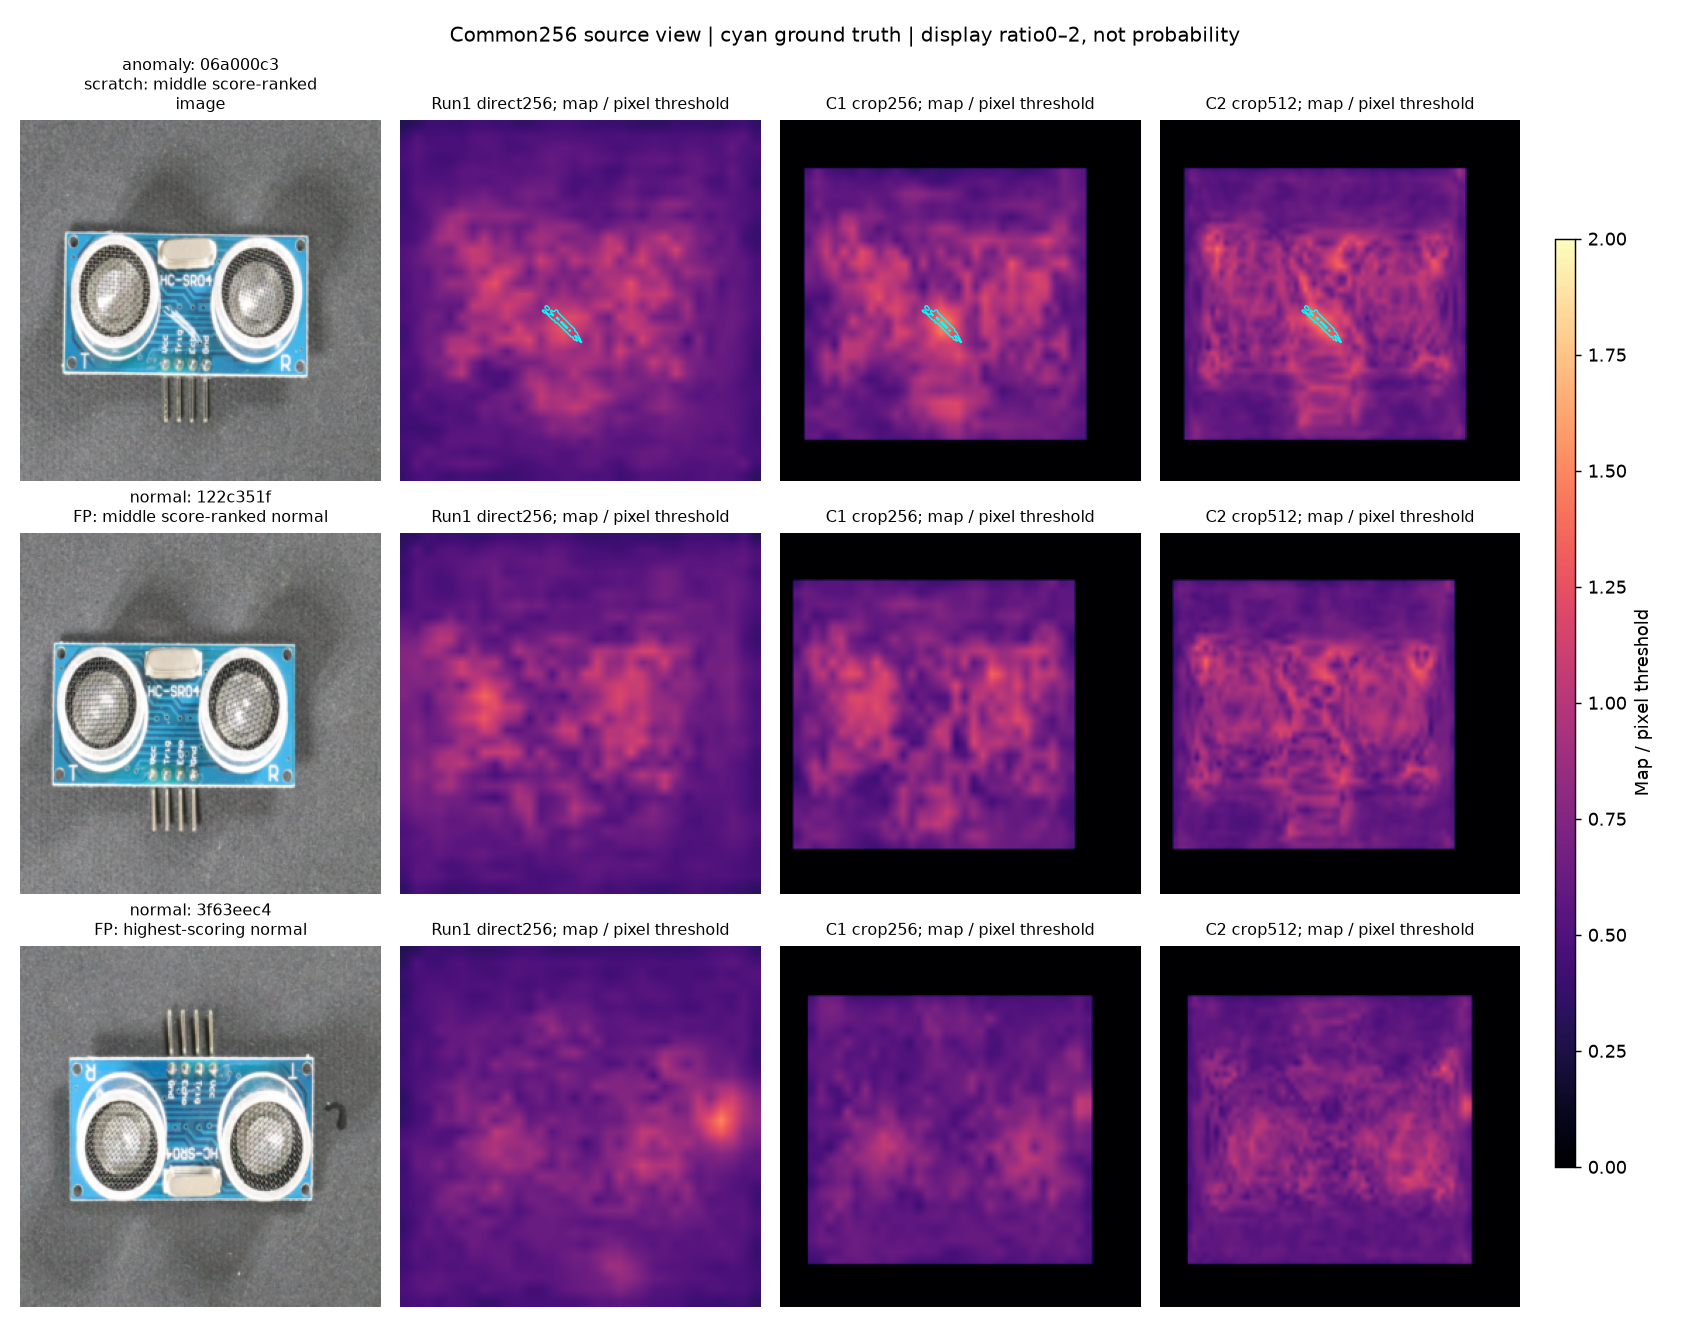

In [5]:
display(pd.read_csv(folder/'qualitative_selection.csv'))
for page in sorted(folder.glob('contact_sheet_*.png')):display(Image(filename=str(page)))

## What this comparison can establish

C1 measures the complete crop/aspect/padding block relative to the original direct
resize. C2 measures resolution under a fixed reference count and reduced coverage.
Neither comparison isolates every preprocessing effect. Source pose is unchanged.
PCB1 has already guided development, so these are development findings. A complete
selected recipe must be frozen before fresh-category PCB2 confirmation.